In [1]:
using Plots
using LinearAlgebra

In [2]:
# Physical parameters
c = 3e8                  # Propagation speed (m/s)
f = 1e9                  # Signal frequency (Hz)
λ = c / f                # Wavelength (m)

# Array parameters
N = 5                  # Number of antenna elements
d = λ / 2                # Element spacing (m)

# Element positions along the x-axis, centred at x = 0
x = ((0:N-1) .- (N-1)/2) .* d

println("Wavelength λ = ", λ, " m")
println("Spacing d    = ", d, " m")
println("Element positions = ", x)

Wavelength λ = 0.3 m
Spacing d    = 0.15 m
Element positions = -0.3:0.15:0.3


In [3]:
# Steering angle
theta_deg = 30
theta = deg2rad(theta_deg)

# Wave number
k = 2 * π / λ

# Steering vector
w = exp.(im .* k .* x .* cos(theta))

# Show the phase of each element
phase_deg = rad2deg.(angle.(w))

println("Steering angle = ", theta_deg, " degrees")
println("Steering phases = ", phase_deg)

Steering angle = 30 degrees
Steering phases = [48.230854637602064, -155.88457268119896, 0.0, 155.88457268119896, -48.230854637602064]


In [4]:
# Phase difference between neighbouring antenna elements
for i = 1:N-1
    phase_diff = angle(w[i+1] * conj(w[i]))
    phase_diff_deg = rad2deg(phase_diff)

    println("Element ", i, " to ", i+1, ": ", phase_diff_deg, " degrees")
end

Element 1 to 2: 155.88457268119896 degrees
Element 2 to 3: 155.88457268119896 degrees
Element 3 to 4: 155.88457268119896 degrees
Element 4 to 5: 155.884572681199 degrees


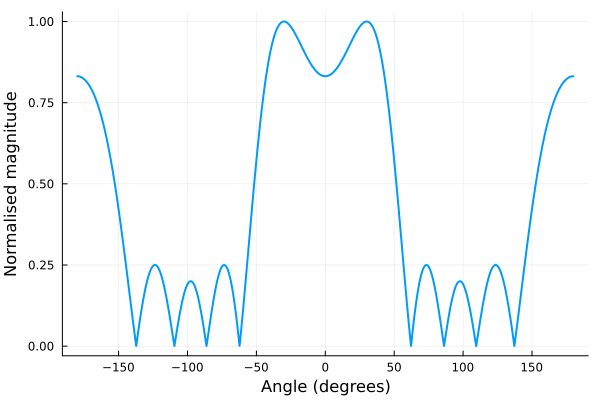

In [5]:
theta_scan_deg = -180:0.1:180
theta_scan = deg2rad.(theta_scan_deg)

response = zeros(length(theta_scan))

for k = 1:length(theta_scan)
    a = exp.(im .* (2 * π / λ) .* x .* cos(theta_scan[k]))
    response[k] = abs(sum(conj.(w) .* a))
end

response = response ./ maximum(response)

plot(theta_scan_deg, response,
    xlabel = "Angle (degrees)",
    ylabel = "Normalised magnitude",
    label = false,
    linewidth = 2)

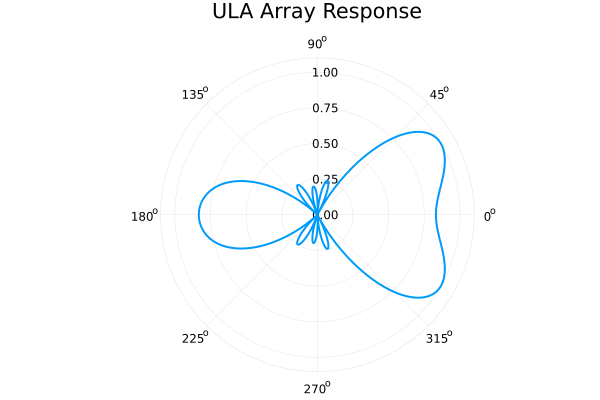

In [6]:
# Polar plot
plot(theta_scan, response,
    proj = :polar,
    label = false,
    linewidth = 2,
    title = "ULA Array Response")

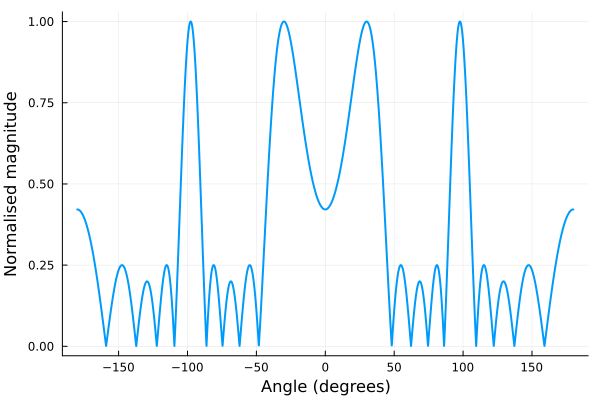

In [7]:
# Increase spacing to one wavelength
d2 = λ

# New antenna positions
x2 = ((0:N-1) .- (N-1)/2) .* d2

# Steering vector for 30 degrees
w2 = exp.(im .* (2 * π / λ) .* x2 .* cos(theta))

# Calculate array response
response2 = zeros(length(theta_scan))

for k = 1:length(theta_scan)
    a = exp.(im .* (2 * π / λ) .* x2 .* cos(theta_scan[k]))
    response2[k] = abs(sum(conj.(w2) .* a))
end

response2 = response2 ./ maximum(response2)

plot(theta_scan_deg, response2,
    xlabel = "Angle (degrees)",
    ylabel = "Normalised magnitude",
    label = false,
    linewidth = 2)

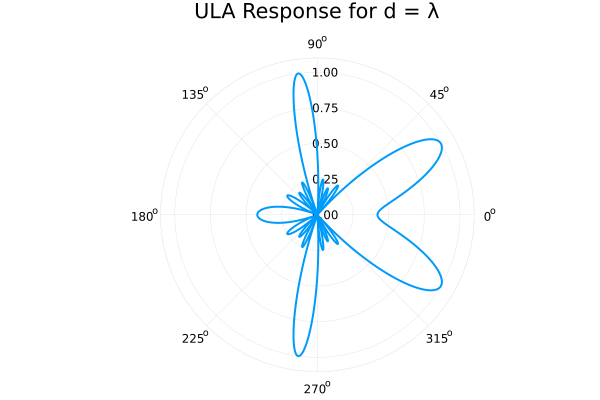

In [8]:
# Polar plot for d = λ
plot(theta_scan, response2,
    proj = :polar,
    label = false,
    linewidth = 2,
    title = "ULA Response for d = λ")

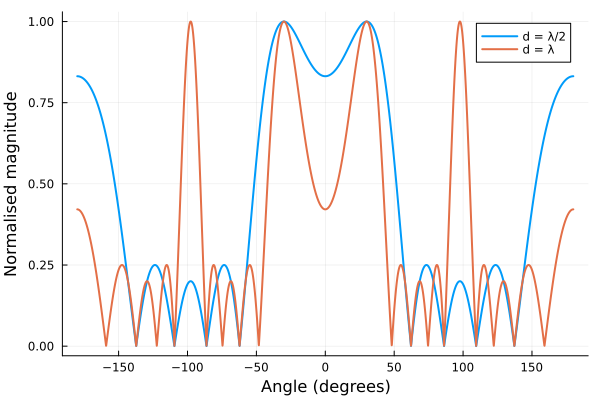

In [9]:
plot(theta_scan_deg, response,
    xlabel = "Angle (degrees)",
    ylabel = "Normalised magnitude",
    label = "d = λ/2",
    linewidth = 2)

plot!(theta_scan_deg, response2,
    label = "d = λ",
    linewidth = 2)

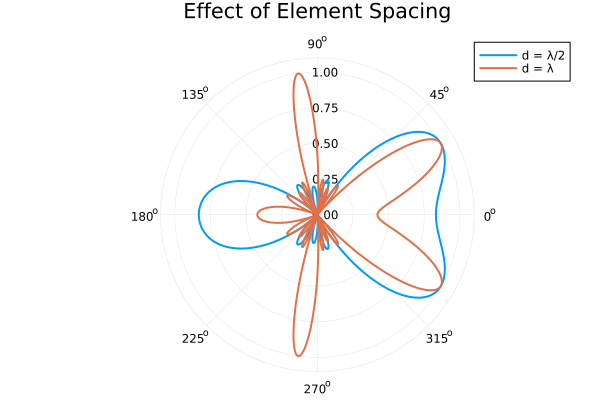

In [10]:
plot(theta_scan, response,
    proj = :polar,
    label = "d = λ/2",
    linewidth = 2)

plot!(theta_scan, response2,
    label = "d = λ",
    linewidth = 2,
    title = "Effect of Element Spacing")

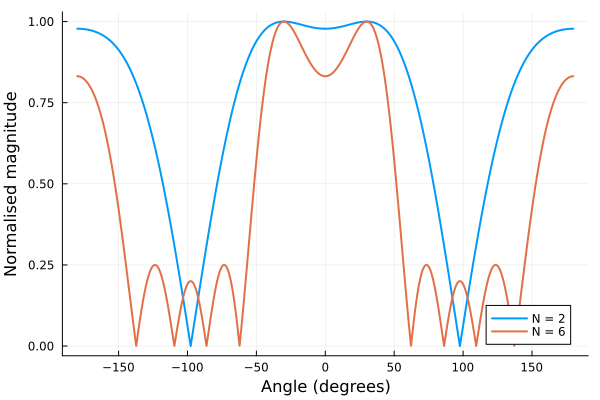

In [11]:
# Two-element array
N2 = 2
d = λ / 2

x_N2 = ((0:N2-1) .- (N2-1)/2) .* d

# Steering vector for 30 degrees
w_N2 = exp.(im .* (2 * π / λ) .* x_N2 .* cos(theta))

# Calculate response
response_N2 = zeros(length(theta_scan))

for k = 1:length(theta_scan)
    a = exp.(im .* (2 * π / λ) .* x_N2 .* cos(theta_scan[k]))
    response_N2[k] = abs(sum(conj.(w_N2) .* a))
end

response_N2 = response_N2 ./ maximum(response_N2)

# Compare 2 and 6 elements
plot(theta_scan_deg, response_N2,
    xlabel = "Angle (degrees)",
    ylabel = "Normalised magnitude",
    label = "N = 2",
    linewidth = 2)

plot!(theta_scan_deg, response,
    label = "N = 6",
    linewidth = 2)

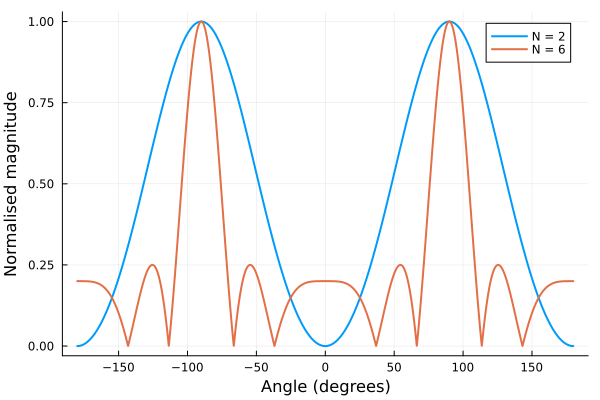

In [12]:
# Broadside steering angle
theta_b = deg2rad(90)

# N = 2 steering vector
w2_b = exp.(im .* (2 * π / λ) .* x_N2 .* cos(theta_b))

response2_b = zeros(length(theta_scan))

for k = 1:length(theta_scan)
    a = exp.(im .* (2 * π / λ) .* x_N2 .* cos(theta_scan[k]))
    response2_b[k] = abs(sum(conj.(w2_b) .* a))
end

response2_b = response2_b ./ maximum(response2_b)


# N = 6 steering vector
w6_b = exp.(im .* (2 * π / λ) .* x .* cos(theta_b))

response6_b = zeros(length(theta_scan))

for k = 1:length(theta_scan)
    a = exp.(im .* (2 * π / λ) .* x .* cos(theta_scan[k]))
    response6_b[k] = abs(sum(conj.(w6_b) .* a))
end

response6_b = response6_b ./ maximum(response6_b)


plot(theta_scan_deg, response2_b,
    label = "N = 2",
    xlabel = "Angle (degrees)",
    ylabel = "Normalised magnitude",
    linewidth = 2)

plot!(theta_scan_deg, response6_b,
    label = "N = 6",
    linewidth = 2)

In [13]:
# Half-power level
half_power = 1 / sqrt(2)

# Only look between 0 and 180 degrees
mask2 = (theta_scan_deg .>= 0) .& (theta_scan_deg .<= 180) .& (response2_b .>= half_power)
mask6 = (theta_scan_deg .>= 0) .& (theta_scan_deg .<= 180) .& (response6_b .>= half_power)

# Angles above the half-power level
angles2 = theta_scan_deg[mask2]
angles6 = theta_scan_deg[mask6]

# Half-power beamwidth
HPBW2 = maximum(angles2) - minimum(angles2)
HPBW5 = maximum(angles6) - minimum(angles6)

println("HPBW for N = 2: ", HPBW2, " degrees")
println("HPBW for N = 5: ", HPBW5, " degrees")

HPBW for N = 2: 60.0 degrees
HPBW for N = 5: 20.599999999999994 degrees
